<a href="https://colab.research.google.com/github/TriBot2o/AI_And_ML_Year3/blob/main/Workshop_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import tensorflow as tf
print(tf.keras.__version__)

3.13.2


In [24]:
### Manual Gradient Calculation in Numpy

import numpy as np

def f(x):
  return x**2

def gradient(x):
  return 2 * x

x = 5.0
learning_rate = 0.1
for _ in range (10):
  x -= learning_rate *gradient(x)
  print(f"x : {x}, f(x): {f(x)}")


x : 4.0, f(x): 16.0
x : 3.2, f(x): 10.240000000000002
x : 2.56, f(x): 6.5536
x : 2.048, f(x): 4.194304
x : 1.6384, f(x): 2.68435456
x : 1.31072, f(x): 1.7179869184000003
x : 1.0485760000000002, f(x): 1.0995116277760004
x : 0.8388608000000002, f(x): 0.7036874417766403
x : 0.6710886400000001, f(x): 0.45035996273704976
x : 0.5368709120000001, f(x): 0.2882303761517119


In [25]:
### Gradient Computations with Keras.

x = tf.Variable(5.0)
with tf.GradientTape() as tape:
  y = x ** 2

grad = tape.gradient(y,x)
print(grad.numpy())

10.0


In [26]:
### Matrix Multiplication Speed (Numpy vs. Tensorflow on GPU).

import numpy as np
import time

size = (1000, 1000)
A = np.random.rand(*size)
B = np.random.rand(*size)

start = time.time()
C_numpy = np.dot(A,B)
print("NumPy Time:",time.time() - start)

A_tf = tf.constant(A)
B_tf = tf.constant(B)

start = time.time()
C_tf = tf.matmul(A_tf,B_tf)
print("TenserFlow Time:", time.time()-start)

NumPy Time: 0.047879695892333984
TenserFlow Time: 0.08246278762817383


In [27]:
### Implementation of Activation Function with Keras.

from tensorflow.keras.layers import Dense

layers = Dense(64, activation='sigmoid')

In [28]:
### Manually Training Network in Numpy.

# for epoch in range(10):
#   y_pred = np.dot(x_train, weights)
#   loss = np.mean((y_pred - y_train)** 2)
#   gradients = 2 * np.dot(x_train.T, (y_pred - y_train)) / len(x_train)
#   weights -= learning_rate * gradients

In [29]:
### keras training is One Line.

#model.fit(x_train,y_train, epochs =10,batch_size=32)

In [30]:
### Layers in Keras.

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
model = Sequential([
    Dense(64,activation = 'relu', input_shape=(784,)),Dense(10,activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
### Implementing SGD in Numpy.

learning_rate = 0.01
weights = np.random.randn(3,3)
for _ in range(100):
  gradient = np.random.randn(3,3)
  weights -= learning_rate *gradient


In [32]:
### In Keras.

from tensorflow.keras.optimizers import SGD
optimizer = SGD(learning_rate = 0.01)

In [33]:
### Example: A Dense Layer with 64 Neurons and sigmoid Activation.

from tensorflow.keras.layers import Dense
layers = Dense(64, activation = "sigmoid")


In [34]:
!unzip -q "/content/drive/MyDrive/AI ML/Data/devnagari digit.zip" -d "/content/drive/MyDrive/AI ML/Data"


replace /content/drive/MyDrive/AI ML/Data/DevanagariHandwrittenDigitDataset/Test/digit_0/103277.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: N
n


Training set: ((17000, 28, 28, 1), (17000, 10))
Testing set: ((3000, 28, 28, 1), (3000, 10))


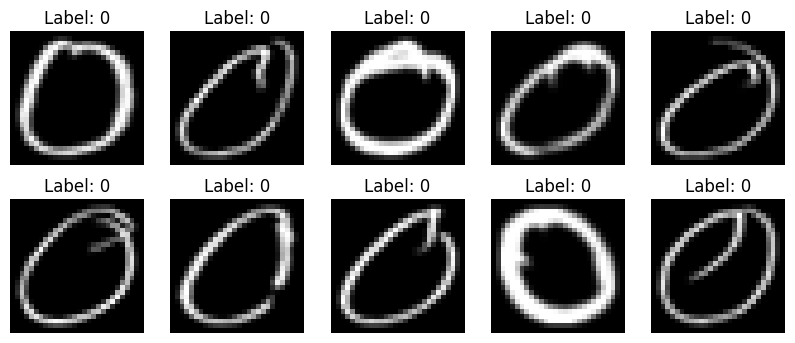

In [35]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image

train_dir = "/content/drive/MyDrive/AI ML/Data/DevanagariHandwrittenDigitDataset/Train"
test_dir = "/content/drive/MyDrive/AI ML/Data/DevanagariHandwrittenDigitDataset/Test"

img_height = 28
img_width =28

def load_images_from_folder(folder):
  images = []
  labels  = []
  class_names = sorted(os.listdir(folder))
  class_map = {name: i for i, name in enumerate(class_names)}
  for class_name in class_names:
    class_path = os.path.join(folder,class_name)
    label = class_map[class_name]
    for filename in os.listdir(class_path):
      img_path = os.path.join(class_path,filename)

      img = Image.open(img_path).convert("L")
      img = img.resize((img_width, img_height))
      img = np.array(img) / 255.0
      images.append(img)
      labels.append(label)
  return np.array(images), np.array(labels)

x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

x_train = x_train.reshape(-1, img_height, img_width, 1)
x_test  = x_test.reshape(-1, img_height, img_width, 1)

y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes = 10)

print(f"Training set: {x_train.shape, y_train.shape}")
print(f"Testing set: {x_test.shape, y_test.shape}")

plt.figure(figsize=(10,4))
for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(x_train[i].reshape(28,28), cmap='gray')
  plt.title(f"Label: {np.argmax(y_train[i])}")
  plt.axis("off")
plt.show()

In [36]:
from tensorflow.keras import layers,models
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train, x_test = x_train / 255.0, x_test / 255.0

x_train = x_train.reshape(-1,28, 28, 1)
x_test = x_test.reshape(-1,28, 28, 1)

y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

In [37]:
### Example using Sequential API.

from tensorflow import keras
num_classes =  10
input_shape = (28,28,1)
model = keras.Sequential(
    [
        keras.layers.Input(shape = input_shape),
        keras.layers.Flatten(),
        keras.layers.Dense(64,activation="sigmoid"),
        keras.layers.Dense(128,activation="sigmoid"),
        keras.layers.Dense(256,activation="sigmoid"),
        keras.layers.Dense(num_classes,activation="softmax"),
    ]
)

In [38]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
### Example using Functional API.

from tensorflow import keras
num_classes = 10
input_shape = (28,28,1)
def build_functional_model():
  inputs = keras.Input(shape= input_shape)

  x = keras.layers.Flatten()(inputs)

  x= keras.layers.Dense(64,activation="sigmoid")(x)
  x= keras.layers.Dense(128,activation="sigmoid")(x)
  x= keras.layers.Dense(256,activation="sigmoid")(x)
  outputs = keras.layers.Dense(num_classes,activation="softmax")(x)
  model  = keras.Model(inputs = inputs, outputs = outputs)
  return model

functional_model = build_functional_model()
functional_model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
### Example: Compiling the Model

model.compile(
    optimizer = "sgd",
    loss = "categorical_crossentropy",
    metrics = ["accuracy"]
)

In [43]:
### Example Code for fit()

batch_size = 128
epochs = 2000

callbacks = [
    keras.callbacks.ModelCheckpoint(filepath="model_at_epoch_{epoch}.keras"),
    keras.callbacks.EarlyStopping(monitor="val_loss",patience=4),
]

history = model.fit(x_train,y_train,batch_size=batch_size,epochs=epochs,validation_split=0.15,callbacks=callbacks,)

Epoch 1/2000
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9727 - loss: 0.0993 - val_accuracy: 0.9661 - val_loss: 0.1149
Epoch 2/2000
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9728 - loss: 0.0990 - val_accuracy: 0.9663 - val_loss: 0.1156
Epoch 3/2000
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9729 - loss: 0.0987 - val_accuracy: 0.9660 - val_loss: 0.1146
Epoch 4/2000
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9730 - loss: 0.0985 - val_accuracy: 0.9666 - val_loss: 0.1145
Epoch 5/2000
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9731 - loss: 0.0982 - val_accuracy: 0.9662 - val_loss: 0.1141
Epoch 6/2000
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9732 - loss: 0.0979 - val_accuracy: 0.9664 - val_loss: 0.1141
Epoch 7/2000
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9732 - loss: 0.0975 - val_accuracy: 0.9660 - val_loss: 0.1144
Epoch 8/2000
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9733 - loss: 0.0973 - 

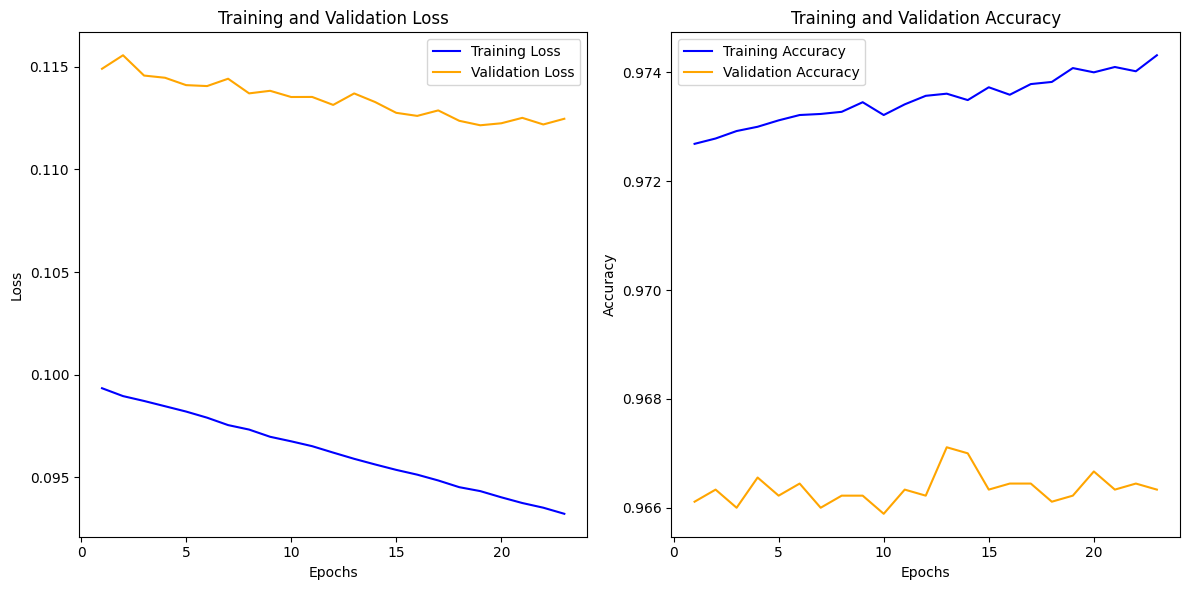

In [44]:
import matplotlib.pyplot as plt
# Assuming ’history’ is the object returned by model.fit()
# Extracting training and validation loss
train_loss = history.history['loss']
val_loss = history.history['val_loss']
# Extracting training and validation accuracy (if metrics were specified)
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
# Plotting training and validation loss
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_loss) + 1), train_loss, label='Training Loss', color='blue')
plt.plot(range(1, len(val_loss) + 1), val_loss, label='Validation Loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
# Plotting training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_acc) + 1), train_acc, label='Training Accuracy', color='blue')
plt.plot(range(1, len(val_acc) + 1), val_acc, label='Validation Accuracy', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [45]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Test accuracy: {test_acc:.4f}")

313/313 - 0s - 1ms/step - accuracy: 0.9631 - loss: 0.1186
Test accuracy: 0.9631


In [46]:
# Predict on test data
predictions = model.predict(x_test)
# Convert predictions from probabilities to digit labels
predicted_labels = np.argmax(predictions, axis=1)
# Check the first prediction
print(f"Predicted label for first image: {predicted_labels[0]}")
print(f"True label for first image: {np.argmax(y_test[0])}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Predicted label for first image: 7
True label for first image: 7


In [51]:
model.save('mnist_fully_connected_model.h5')

In [54]:
loaded_model = tf.keras.models.load_model('mnist_fully_connected_model.h5')

In [ ]:
#/content/mnist_fully_connected_model.keras
#/content/mnist_fully_connected_model.h5